# momapy-kb: a python library to integrate maps in neo4j

Currently `momapy-kb` is a python library to integrate maps into Neo4j. It relies on two other libraries:
* `momapy`, a library for working with maps
* `fieldz-kb`, a library for integrating dataclass-like python objects into Neo4j using the `neomodel` OGM

## Fieldz-kb

In [1]:
import dataclasses
import fieldz_kb.neo4j.core
import neo4j
import credentials

### Storing python objects to Neo4j automatically

We make a simple object class:

In [2]:
@dataclasses.dataclass
class A:
    w: int | None = None # optional
    x: list[str] = dataclasses.field(default_factory=list) # a list of strings

In [3]:
a = A(1, ["a", "b", "c", "d"])

We connect to the database, and remove all its content:

In [4]:
fieldz_kb.neo4j.core.connect(credentials.HOST_NAME, credentials.USER_NAME, credentials.PASSWORD, notifications_min_severity="off") # connection

In [5]:
fieldz_kb.neo4j.core.delete_all()

We save the object we made to the database using the `save_from_object` function:

In [6]:
fieldz_kb.neo4j.core.save_from_object(a)

We can make complex objects, i.e., objects that contain other self-defined objects, and save them to the database using the same function:

In [7]:
@dataclasses.dataclass
class B:
    y: float # a required float
    z: list[A] = dataclasses.field(default_factory=list) # a list of As

In [8]:
a1 = A(1, ["a1_1", "a1_2"])
a2 = A(2, ["a2_1", "a2_2"])
b = B(1.0, [a1, a2])

In [9]:
fieldz_kb.neo4j.core.save_from_object(b)

The transformation is based on the `neomodel` Object-Graph-Mapper (OGM). It goes as follows:
* python object -> OGM node -> Neo4j node (in the database)

OGM nodes have a structure that reflects the one of the python objects, and serve as an intermediate between the objects and Neo4j.
<br> `fieldz-kb` transforms dataclass-like python objects to OGM nodes, while the storage/retrieval of OGM nodes to/from Neo4j is handeled by `neomodel`.

### Integration modes

We can integrate objects in the database based on their:
* `id` for an identity-based integration;
* `hash` (if hashable) for an equality-based integration.

By default, objects are not integrated, i.e., objects that are the same are modeled using different nodes:

In [10]:
b = B(1.0, [a1, a1]) # b has two a1
fieldz_kb.neo4j.core.delete_all()
fieldz_kb.neo4j.core.save_from_object(b)

We have two nodes for `a1` in the database:

In [11]:
query = "MATCH (n:A) RETURN n"
results, meta = fieldz_kb.neo4j.core.cypher_query(query)
assert len(results) == 2

With the integration mode enabled, objects that are the same are modeled using the same node:

In [12]:
fieldz_kb.neo4j.core.delete_all()
fieldz_kb.neo4j.core.save_from_object(b, integration_mode="id")

We have only one node for `a1` in the database:

In [13]:
query = "MATCH (n:A) RETURN n"
results, meta = fieldz_kb.neo4j.core.cypher_query(query)
assert len(results) == 1

### Re-building objects from nodes

We can query nodes, and transform them back to python objects using the `make_object_from_node`.
<br>When we query the nodes, we must use the `resolve_objects` option, so that OGM nodes are returned from the query, and not plain Neo4j nodes.
<br>The transformation goes as follows:
* Neo4j node (in the database) -> OGM node -> python object

Here, we query one B node, and transform it back to a python object:

In [14]:
query = "MATCH (n:B) RETURN n LIMIT 1"
results, meta = fieldz_kb.neo4j.core.cypher_query(query, resolve_objects=True) # the resolve_objects option is required
node = results[0][0] # an OGM node
obj = fieldz_kb.neo4j.core.make_object_from_node(node)

The object we obtain is the same as the one we stored in the database:

In [15]:
assert obj == b

We can also query and transform the result back to objects directly using the `cypher_query_as_objects` function:

In [16]:
query = "MATCH (n:B) RETURN n LIMIT 1"
results, meta = fieldz_kb.neo4j.core.cypher_query_as_objects(query)
obj = results[0][0] # directly a python object
assert obj == b

## Momapy-kb

`momapy-kb` is based on `fieldz-kb` and `momapy`; it just offers convenience functions built around the two packages, to apply `fieldz-kb` capabilities to `momapy` maps.

In [17]:
import momapy_kb.neo4j.core
from utils import display

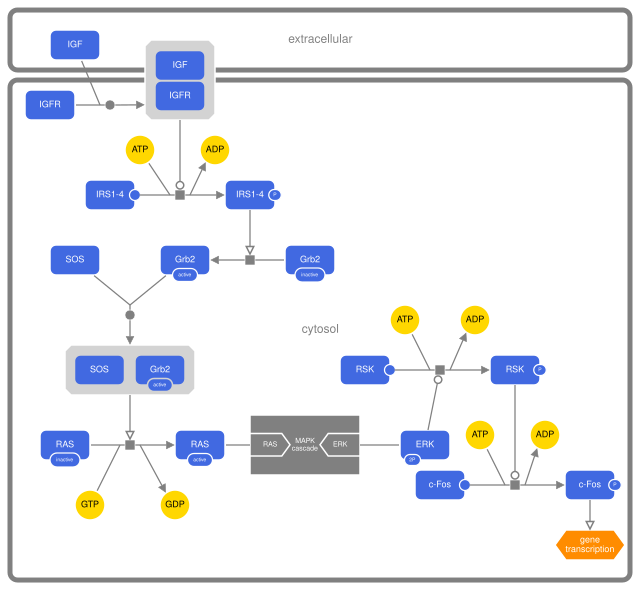

In [18]:
display("insulin.sbgn", scale=0.5, style_sheet="mk.css")

### Functions from fieldz-kb

`momapy-kb` gives access to the following functions of `fieldz-kb`:
* connect
* delete_all
* save_from_object
* make_nodes_from_object
* make_object_from_node
* cypher_query_as_objects

and introduces new fuctions:
* save_from_file
* get_layout_element_nodes_from_model_element_node
* make_layout_elements_from_model_element_node
* cypher_query_as_layout_elements

### Read and save momapy objects directly from a file

We can save a map directly from a file:

In [19]:
momapy_kb.neo4j.core.delete_all()
momapy_kb.neo4j.core.save_from_file("insulin.sbgn", integration_mode="hash")

We can also save only the model (resp. layout), using the `return_type` option:

In [20]:
momapy_kb.neo4j.core.delete_all()
momapy_kb.neo4j.core.save_from_file("insulin.sbgn", return_type="model", integration_mode="hash")

### Querying

#### Using the OGM

For simple queries, the OGM can be used:

In [21]:
import momapy_kb.neo4j.sbgn.pd

We query all macromolecule nodes (OGM):

In [22]:
macromolecule_nodes = momapy_kb.neo4j.sbgn.pd.Macromolecule.nodes.all()

We query all "c-Fos" macromolecule nodes (OGM):

In [23]:
print(len(macromolecule_nodes))

14


In [24]:
c_fos_nodes = momapy_kb.neo4j.sbgn.pd.Macromolecule.nodes.filter(label__exact="c-Fos")
print(len(c_fos_nodes))

2


#### Using Cypher

Simple and more complex queries can be expressed using Cypher.

We query all macromolecules nodes (Neo4j):

In [25]:
query = "MATCH (n:Macromolecule) RETURN n"
results, meta = momapy_kb.neo4j.core.cypher_query(query)
assert len(results) == 14

We query all phosphorylation processes (OGM):

In [26]:
query = """
    MATCH (p:GenericProcess),
    (p)-[:HAS_REACTANT]->()-[:HAS_ELEMENT]->(reactant)-[:HAS_STATE_VARIABLE]->(reactant_sv),
    (p)-[:HAS_PRODUCT]->()-[:HAS_ELEMENT]->(product)-[:HAS_STATE_VARIABLE]->(product_sv)
    WHERE reactant.label = product.label
    AND reactant_sv.value IS NULL AND product_sv.value = "P"
    AND (reactant_sv.variable IS NULL AND product_sv.variable IS NULL and reactant_sv.order = product_sv.order
    OR reactant_sv.variable = product_sv.variable)
    RETURN p
"""
results, meta = momapy_kb.neo4j.core.cypher_query(query, resolve_objects=True)
print(len(results))

3


### Rendering query results as map excerpts

We store the whole map to Neo4j (model + layout + layout model mapping):

In [27]:
momapy_kb.neo4j.core.delete_all()
momapy_kb.neo4j.core.save_from_file("insulin.sbgn", return_type="map", integration_mode="hash")

We query all macromolecules from the model; we use the `resolve_objects` option to transform the result into nodes:

In [28]:
query = "MATCH (n:Macromolecule) RETURN n"
results, _ = momapy_kb.neo4j.core.cypher_query(query, resolve_objects=True)

For the three first macromolecule nodes in the result of our query, we fetch the corresponding layout element nodes in the database and transform them to layout element objects using the `make_layout_elements_from_model_element_node` function:

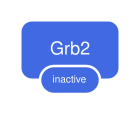

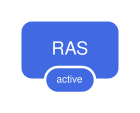

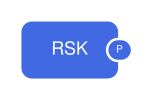

In [29]:
for row in results[:3]:
    macromolecule_node = row[0] # only one macromolecule node by row
    layout_elements = momapy_kb.neo4j.core.make_layout_elements_from_model_element_node(macromolecule_node)
    display(layout_elements, style_sheet="mk.css")

We do the same for phosphorylation processes, this time directly obtaining the layout element objects from the query, with no intermediate nodes, using the `cypher_query_as_layout_elements` function:

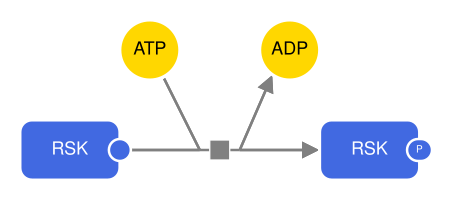

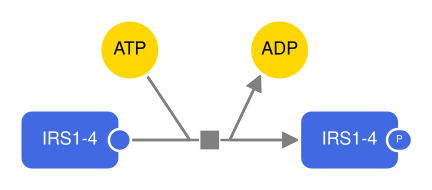

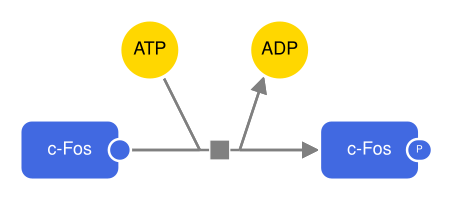

In [30]:
query = """
    MATCH (p:GenericProcess),
    (p)-[:HAS_REACTANT]->()-[:HAS_ELEMENT]->(reactant)-[:HAS_STATE_VARIABLE]->(reactant_sv),
    (p)-[:HAS_PRODUCT]->()-[:HAS_ELEMENT]->(product)-[:HAS_STATE_VARIABLE]->(product_sv)
    WHERE reactant.label = product.label
    AND reactant_sv.value IS NULL AND product_sv.value = "P"
    AND (reactant_sv.variable IS NULL AND product_sv.variable IS NULL and reactant_sv.order = product_sv.order
    OR reactant_sv.variable = product_sv.variable)
    RETURN p
"""
results, _ = momapy_kb.neo4j.core.cypher_query_as_layout_elements(query)
for layout_elements in results:
        display(layout_elements, style_sheet="mk.css")

In the previous example, each row of the result was displayed independently (and pushed to the top left corner of the canvas); we can also merge all rows to have a global view of the result, reflecting the layout of the original map:

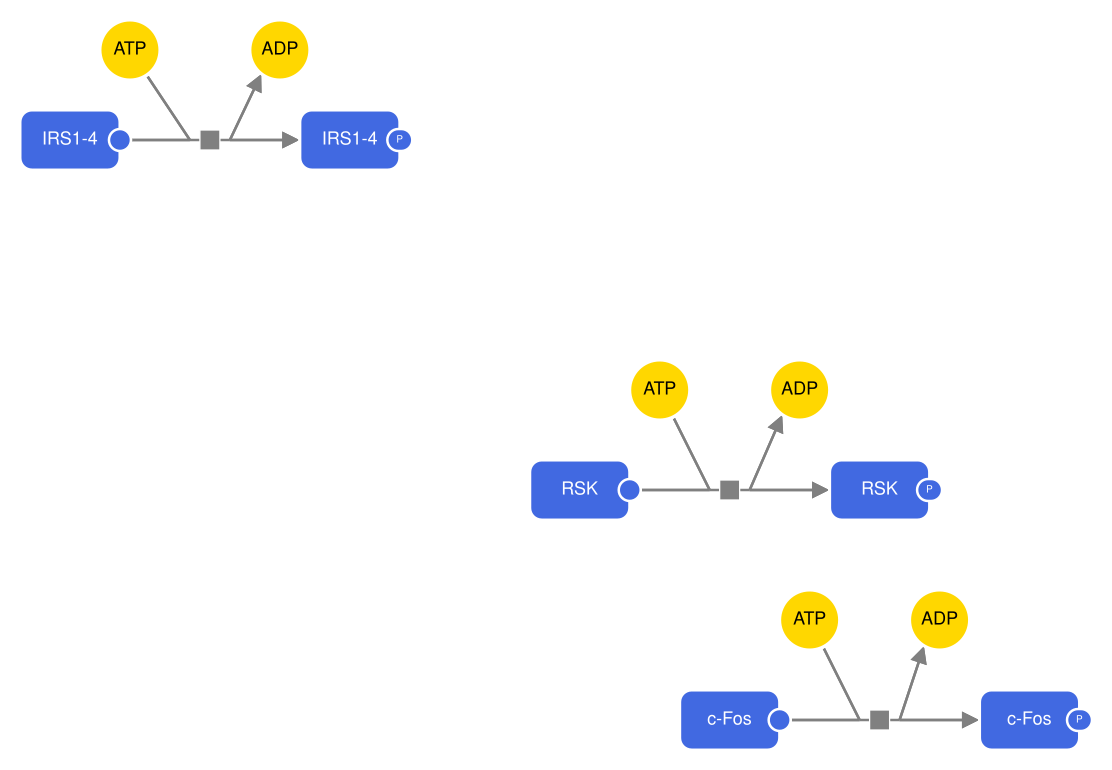

In [31]:
layout_elements = sum(results, [])
display(layout_elements, style_sheet="mk.css")

## Future work

* Additonal backends (`fieldz-kb`):
    - Kuzu: Cypher, serverless, faster than Neo4j (but only one label per Node)
    - Answer Set Programming: for complex problems, reasoning, transformation (e.g., PD to AF); based on `clorm` (ORM)
    - RDF?
* Webapp based on `momapy-kb` (Neo4j) to integrate and query maps:
    - Store/integrate/query maps (some functions already in `neo4j-dm` to create integrated collections of maps)
    - Visualize results: as graphs/text (same as Neo4j-browser); as excerpts of maps; have per row and global views; use SVG rendering
* New tool for natural language querying (Neo4j):
    - Based on LLMs (MCP+`SBGN bricks`)
    - Integrated to the Webapp